# Joint Optimization: Feature Selection & Hyperparameter Tuning (Hybrid PSO-GA)

This notebook implements the final, most advanced stage of the project: **Joint Optimization**.
Instead of optimizing features and parameters separately, we optimize them simultaneously using a Hybrid PSO-GA.

**Rationale:**
A subset of features that performs well with a default Decision Tree might perform poorly with a deeply constrained tree, and vice versa. Joint optimization searches for the **Global Optimum** in the combined space of `{Features} x {Hyperparameters}`.

**Particle Representation:**
Each particle is a vector divided into two segments:
1.  **Feature Segment**: Binary values representing selected features.
2.  **Parameter Segment**: Continuous values mapped to hyperparameters (max_depth, min_samples_split, criterion).

In [7]:
import os
import pandas as pd 
import numpy as np
import time
import json
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from joblib import Parallel, delayed
from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

In [8]:
data_path = Path("data/processed/processed_cicids2017.csv")
if not data_path.exists():
    data_path = Path("../data/processed/processed_cicids2017.csv")
if not data_path.exists():
    raise FileNotFoundError(
        "Could not find processed dataset. Run: python main.py --mode preprocess"
    )

df = pd.read_csv(data_path)
df.dropna(inplace=True)

X = df.drop(columns=['Label'])
y = df['Label']
feature_names = X.columns.tolist()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dataset Path: {data_path.resolve()}")
print(f"Total Features: {X.shape[1]}")
print(f"Training Samples: {X_train.shape[0]}")

Dataset Path: C:\Users\user\Desktop\AI Methods\Intrusion-Detection-System\data\processed\processed_cicids2017.csv
Total Features: 77
Training Samples: 201663


In [9]:
class Joint_PSOGA_Optimizer:
    def __init__(self, X_train, y_train, n_particles=20, n_iterations=10, n_jobs=4, alpha=0.005):
        self.X_train = X_train
        self.y_train = y_train
        self.n_particles = n_particles
        self.n_iterations = n_iterations
        self.n_jobs = n_jobs
        self.alpha = alpha  # Weight for feature reduction
        
        # Dimensions
        self.n_features = X_train.shape[1]
        self.n_params = 3 # max_depth, min_samples_split, criterion
        self.total_dim = self.n_features + self.n_params
        
        # PSO Params
        self.w = 0.729    # Inertia weight
        self.c1 = 1.49445 # Cognitive (Personal)
        self.c2 = 1.49445 # Social (Global)
        self.v_max = 0.2  # Velocity clamping
        self.mutation_rate = 0.05 
        
        # Split Valid for internal fitness
        self.X_sub, self.X_val, self.y_sub, self.y_val = train_test_split(
            self.X_train, self.y_train, test_size=0.2, random_state=42, stratify=self.y_train
        )
        
        # Initialize Population (Continuous [0, 1])
        self.positions = np.random.uniform(0, 1, size=(self.n_particles, self.total_dim))
        self.velocities = np.random.uniform(-self.v_max, self.v_max, size=(self.n_particles, self.total_dim))
        
        # Best tracking
        self.pbest_pos = self.positions.copy()
        self.pbest_scores = np.full(self.n_particles, -1.0)
        
        self.gbest_pos = None
        self.gbest_score = -1.0
        
        self.history = {'iteration': [], 'accuracy': [], 'features': [], 'fitness': []}
        self.training_time = 0
        self.pbar = None

    def decode_particle(self, particle):
        """
        Decodes the continuous particle vector into:
        1. Feature Mask (Binary)
        2. Hyperparameters (Discrete/Category)
        """
        # Segment A: Features (First n_features dimensions)
        feature_vals = particle[:self.n_features]
        # Threshold at 0.5 to activate feature
        selected_indices = np.where(feature_vals > 0.5)[0]
        
        # Segment B: Parameters (Last 3 dimensions)
        param_vals = particle[self.n_features:]
        
        # Param 1: max_depth [0,1] -> Int [1, 30]
        p0 = np.clip(param_vals[0], 0, 0.9999)
        max_depth = 1 + int(p0 * 29)
        
        # Param 2: min_samples_split [0,1] -> Int [2, 20]
        p1 = np.clip(param_vals[1], 0, 0.9999)
        min_split = 2 + int(p1 * 18)
        
        # Param 3: criterion [0,1] -> {0: gini, 1: entropy}
        p2 = np.clip(param_vals[2], 0, 0.9999)
        criterion = 'entropy' if p2 > 0.5 else 'gini'
        
        return selected_indices, {'max_depth': max_depth, 'min_samples_split': min_split, 'criterion': criterion}

    def calculate_fitness(self, particle):
        selected_indices, params = self.decode_particle(particle)
        
        # Valid solution check: Must select at least 1 feature
        if len(selected_indices) == 0:
            return 0.0
            
        X_sub_sel = self.X_sub[:, selected_indices]
        X_val_sel = self.X_val[:, selected_indices]
        
        # Train with decoded parameters
        clf = DecisionTreeClassifier(
            max_depth=params['max_depth'],
            min_samples_split=params['min_samples_split'],
            criterion=params['criterion'],
            random_state=42
        )
        clf.fit(X_sub_sel, self.y_sub)
        pred = clf.predict(X_val_sel)
        
        acc = accuracy_score(self.y_val, pred)
        
        # Multi-objective Fitness: Maximize Acc, Minimize Features
        # Fitness = Acc + alpha * (1 - (selected / total))
        # This gives a small boost to simpler models with same accuracy
        feat_ratio = len(selected_indices) / self.n_features
        fitness = acc + self.alpha * (1 - feat_ratio)
        
        return fitness

    def _evaluate_batch(self, population):
        # Threading backend is crucial for Windows + Jupyter environment
        scores = Parallel(n_jobs=self.n_jobs, backend="threading")(
            delayed(self.calculate_fitness)(ind) for ind in population
        )
        return np.array(scores)

    def run(self):
        print(f"Starting Joint Optimization with {self.n_particles} particles...")
        start_time = time.time()
        
        # Initial Eval
        scores = self._evaluate_batch(self.positions)
        self.pbest_scores = scores.copy()
        
        best_idx = np.argmax(scores)
        self.gbest_pos = self.positions[best_idx].copy()
        self.gbest_score = scores[best_idx]
        
        self.pbar = tqdm(total=self.n_iterations)
        
        for iteration in range(self.n_iterations):
            # --- PSO Update ---
            for i in range(self.n_particles):
                r1, r2 = np.random.rand(), np.random.rand()
                
                # Velocity Update
                self.velocities[i] = (self.w * self.velocities[i] +
                                      self.c1 * r1 * (self.pbest_pos[i] - self.positions[i]) +
                                      self.c2 * r2 * (self.gbest_pos - self.positions[i]))
                
                # Velocity Clamping (Crucial for stability)
                self.velocities[i] = np.clip(self.velocities[i], -self.v_max, self.v_max)
                
                # Position Update
                self.positions[i] = self.positions[i] + self.velocities[i]
                self.positions[i] = np.clip(self.positions[i], 0, 1)

            # --- GA Hybrid Mutation (Probalistic) ---
            # Instead of replacing worst, we mutate a random subset of the population
            # Best practice: Don't mutate the Global Best
            
            non_best_indices = [idx for idx in range(self.n_particles) if np.array_equal(self.positions[idx], self.gbest_pos) == False]
            if len(non_best_indices) > 0:
                # Select 10-20% to mutate
                n_mutants = max(1, int(len(non_best_indices) * 0.2))
                mutant_indices = np.random.choice(non_best_indices, n_mutants, replace=False)
                
                for idx in mutant_indices:
                    # Gene-wise mutation
                    mask = np.random.rand(self.total_dim) < self.mutation_rate
                    # Assign new random values to mutated genes
                    self.positions[idx][mask] = np.random.rand(np.sum(mask))

            # Evaluate
            current_scores = self._evaluate_batch(self.positions)
            
            # Update Bests
            for i in range(self.n_particles):
                if current_scores[i] > self.pbest_scores[i]:
                    self.pbest_scores[i] = current_scores[i]
                    self.pbest_pos[i] = self.positions[i].copy()
                
                if current_scores[i] > self.gbest_score:
                    self.gbest_score = current_scores[i]
                    self.gbest_pos = self.positions[i].copy()
            
            # --- History Tracking ---
            # Extract Accuracy and Feature Count from Global Best
            best_ind, _ = self.decode_particle(self.gbest_pos)
            feat_count = len(best_ind)
            
            # Reverse engineer accuracy from fitness
            # Fitness = Acc + alpha * (1 - feat_ratio)
            # Acc = Fitness - alpha * (1 - feat_ratio)
            feat_ratio = feat_count / self.n_features
            est_acc = self.gbest_score - self.alpha * (1 - feat_ratio)
            
            self.history['fitness'].append(self.gbest_score)
            self.history['accuracy'].append(est_acc)
            self.history['features'].append(feat_count)
            self.history['iteration'].append(iteration + 1)
            
            self.pbar.update(1)
            self.pbar.set_description(f"Best Fitness: {self.gbest_score:.4f} | Acc: {est_acc:.4f}")
            
        end_time = time.time()
        self.training_time = end_time - start_time
        
        self.pbar.close()
        print(f"Joint Optimization execution complete. Time taken: {self.training_time:.2f} seconds.")
        return self.gbest_pos, self.gbest_score, self.history

    def get_runtime(self):
        return self.training_time

Using 12 CPU cores for processing.
Starting Joint Optimization with 30 particles...


  0%|          | 0/20 [00:00<?, ?it/s]

Joint Optimization execution complete. Time taken: 219.88 seconds.

--- Optimization Complete ---
Best Fitness Score: 1.0000
Optimal Hyperparameters: {'max_depth': 21, 'min_samples_split': 12, 'criterion': 'entropy'}
Selected Features (30/77): ['Destination Port', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Max', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Min', 'Bwd IAT Max', 'Bwd PSH Flags', 'Bwd URG Flags', 'Bwd Header Length', 'Min Packet Length', 'Packet Length Mean', 'Packet Length Variance', 'FIN Flag Count', 'ACK Flag Count', 'URG Flag Count', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Bwd Packets', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'Active Mean', 'Active Min', 'Idle Mean', 'Idle Min']
Computational Cost (Runtime): 219.8815 seconds


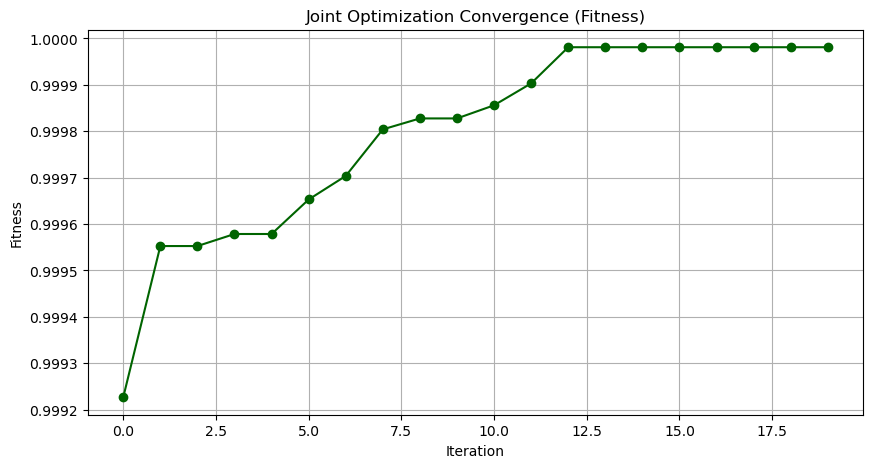

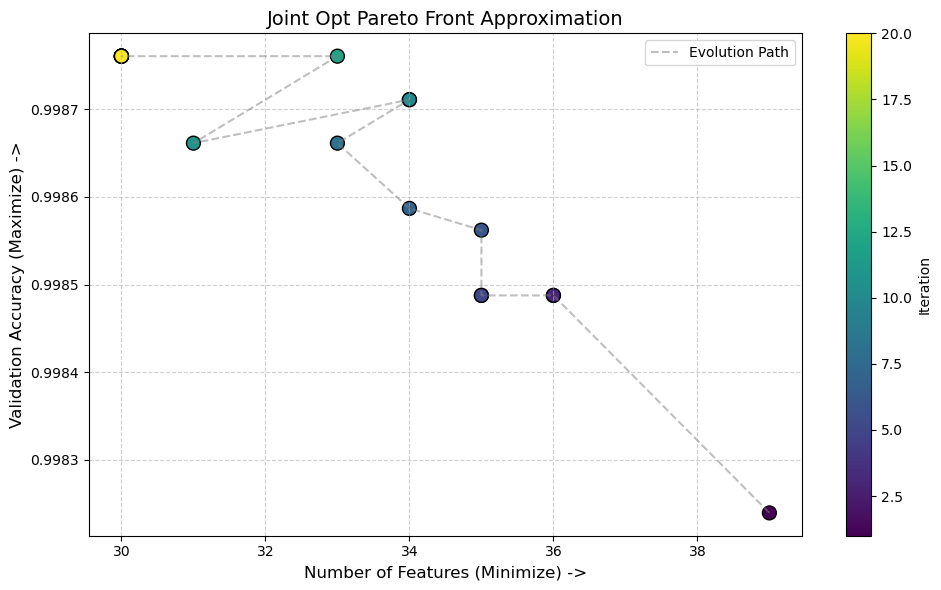

In [10]:
# Run Joint Optimization
# Use available CPU cores
n_jobs = os.cpu_count()
print(f"Using {n_jobs} CPU cores for processing.")

# Alpha=0.002 means 100% accuracy with 10 features is better than 100% accuracy with 50 features.
# But 99% accuracy is still better than 98% accuracy regardless of features.
optimizer = Joint_PSOGA_Optimizer(X_train_scaled, y_train, n_particles=30, n_iterations=20, n_jobs=n_jobs, alpha=0.002)
best_vector, best_fitness, history = optimizer.run()

# Decode Final Solution
final_indices, final_params = optimizer.decode_particle(best_vector)
final_features = [feature_names[i] for i in final_indices]
runtime = optimizer.get_runtime()

print("\n--- Optimization Complete ---")
print(f"Best Fitness Score: {best_fitness:.4f}")
print(f"Optimal Hyperparameters: {final_params}")
print(f"Selected Features ({len(final_features)}/{len(feature_names)}): {final_features}")
print(f"Computational Cost (Runtime): {runtime:.4f} seconds")

# Plot Convergence
plt.figure(figsize=(10, 5))
plt.plot(history['fitness'], marker='o', color='darkgreen')
plt.title('Joint Optimization Convergence (Fitness)')
plt.xlabel('Iteration')
plt.ylabel('Fitness')
plt.grid(True)
plt.show()

# --- Pareto Front Visualization ---
plt.figure(figsize=(10, 6))
# Evolution Path
plt.plot(history['features'], history['accuracy'], color='gray', linestyle='--', alpha=0.5, label='Evolution Path')
# Points (Iterations)
plt.scatter(history['features'], history['accuracy'], c=history['iteration'], cmap='viridis', s=100, edgecolors='black')

plt.colorbar(label='Iteration')
plt.title('Joint Opt Pareto Front Approximation', fontsize=14)
plt.xlabel('Number of Features (Minimize) ->', fontsize=12)
plt.ylabel('Validation Accuracy (Maximize) ->', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


Training Final Joint Optimized Model on Test Set...

Classification Report (Joint Optimized Features & Params):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     41901
           1       0.99      1.00      1.00      8515

    accuracy                           1.00     50416
   macro avg       1.00      1.00      1.00     50416
weighted avg       1.00      1.00      1.00     50416

=== Joint Optimization Final Metrics ===
Accuracy: 0.9983933671850206
Precision: 0.998395046100232
Recall: 0.9983933671850206
F1-Score: 0.9983940052934934
Detection Rate (TPR): 0.9962419260129184
False Positive Rate (FPR): 0.0011694231641249612
Feature Count: 30
Runtime (s): 219.88153791427612
Best Params: {'max_depth': 21, 'min_samples_split': 12, 'criterion': 'entropy'}


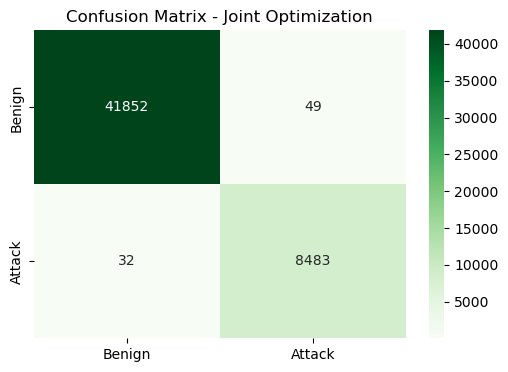

Loaded baseline metrics from C:\Users\user\Desktop\AI Methods\Intrusion-Detection-System\results\results\baseline_metrics.json
Joint metrics saved to C:\Users\user\Desktop\AI Methods\Intrusion-Detection-System\results\joint_metrics.json

=== Model Comparison Results ===
                            Baseline  Joint Optimization
Accuracy                    0.998155            0.998393
Precision                   0.998155            0.998395
Recall                      0.998155            0.998393
F1-Score                    0.998155            0.998394
Detection Rate (TPR)        0.994363            0.996242
False Positive Rate (FPR)   0.001074            0.001169
Feature Count              69.000000           30.000000


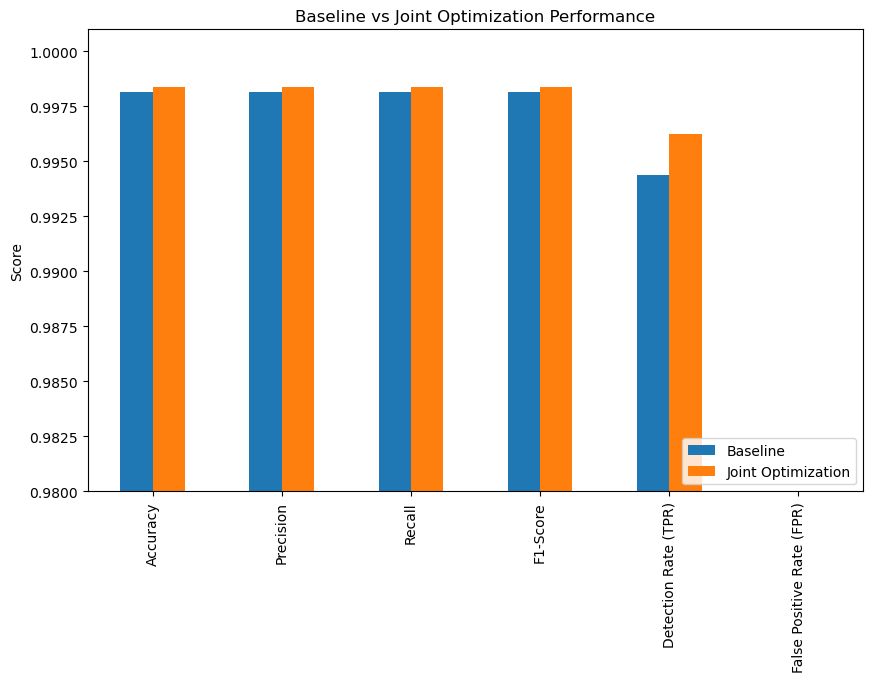

Reduction in Features: 56.52%
Optimized Hyperparameters: {'max_depth': 21, 'min_samples_split': 12, 'criterion': 'entropy'}


In [14]:
# Final Comparison: Joint Optimized vs Baseline

# 1. Train Joint Optimized Model
print("\nTraining Final Joint Optimized Model on Test Set...")

# Use the indices found by the optimizer
X_train_joint = X_train_scaled[:, final_indices]
X_test_joint = X_test_scaled[:, final_indices]

# Use the hyperparameters found by the optimizer
joint_model = DecisionTreeClassifier(
    max_depth=final_params['max_depth'],
    min_samples_split=final_params['min_samples_split'],
    criterion=final_params['criterion'],
    random_state=42
)
joint_model.fit(X_train_joint, y_train)

y_pred_joint = joint_model.predict(X_test_joint)

# Evaluation
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_joint).ravel()

joint_acc = accuracy_score(y_test, y_pred_joint)
joint_prec = precision_score(y_test, y_pred_joint, average='weighted')
joint_rec = recall_score(y_test, y_pred_joint, average='weighted')
joint_f1 = f1_score(y_test, y_pred_joint, average='weighted')

detection_rate_joint = tp / (tp + fn)
false_positive_rate_joint = fp / (fp + tn)

print("\nClassification Report (Joint Optimized Features & Params):")
print(classification_report(y_test, y_pred_joint))

# Metrics Dict
joint_final_metrics = {
    'Accuracy': joint_acc,
    'Precision': joint_prec,
    'Recall': joint_rec,
    'F1-Score': joint_f1,
    'Detection Rate (TPR)': detection_rate_joint,
    'False Positive Rate (FPR)': false_positive_rate_joint,
    'Feature Count': len(final_features),
    'Runtime (s)': runtime,
    'Best Params': str(final_params)
}

print("=== Joint Optimization Final Metrics ===")
for k, v in joint_final_metrics.items():
    print(f"{k}: {v}")

conf_matrix_joint = confusion_matrix(y_test, y_pred_joint)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_joint, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
plt.title('Confusion Matrix - Joint Optimization')
plt.show()

# --- Comparison with Baseline ---
# Resolve project-aware paths so notebook works from both project root and notebooks/
project_root = data_path.resolve().parents[2] if 'data_path' in globals() else Path.cwd()
results_dir = project_root / 'results'
results_dir.mkdir(parents=True, exist_ok=True)

# 1. Load Baseline Mean Metrics from JSON
baseline_candidates = [
    results_dir / 'baseline_metrics.json',
    results_dir / 'results' / 'baseline_metrics.json',
]

baseline_metrics = None
for baseline_path in baseline_candidates:
    if baseline_path.exists():
        with open(baseline_path, 'r') as f:
            baseline_metrics = json.load(f)
        print(f"Loaded baseline metrics from {baseline_path}")
        break

if baseline_metrics is None:
    print("Warning: baseline_metrics.json not found. Using default placeholder values.")
    baseline_metrics = {
        'Accuracy': 0.9982,
        'Precision': 0.9982,
        'Recall': 0.9982,
        'F1-Score': 0.9982,
        'Detection Rate (TPR)': 0.9947,
        'False Positive Rate (FPR)': 0.001,
        'Feature Count': 77
    }

joint_metrics = {
    'Method': 'Joint Optimization',
    'Accuracy': joint_acc,
    'Precision': joint_prec,
    'Recall': joint_rec,
    'F1-Score': joint_f1,
    'Detection Rate (TPR)': detection_rate_joint,
    'False Positive Rate (FPR)': false_positive_rate_joint,
    'Feature Count': len(final_features),
    'Runtime (s)': runtime
}

# --- SAVE METRICS to JSON ---
joint_metrics_path = results_dir / 'joint_metrics.json'
with open(joint_metrics_path, 'w') as f:
    json.dump(joint_metrics, f, indent=4)
print(f"Joint metrics saved to {joint_metrics_path}")

# Visualization
metrics_keys = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Detection Rate (TPR)', 'False Positive Rate (FPR)', 'Feature Count']
baseline_filtered = {k: baseline_metrics.get(k, 0) for k in metrics_keys}
joint_filtered = {k: joint_metrics.get(k, 0) for k in metrics_keys}

results_df = pd.DataFrame([baseline_filtered, joint_filtered], index=['Baseline', 'Joint Optimization'])
print("\n=== Model Comparison Results ===")
print(results_df.T)

results_without_count = results_df.drop('Feature Count', axis=1)
results_without_count.T.plot(kind='bar', figsize=(10, 6))
plt.title('Baseline vs Joint Optimization Performance')
plt.ylabel('Score')
plt.ylim(0.98, 1.001)
plt.legend(loc='lower right')
plt.show()

print(f"Reduction in Features: {((baseline_metrics['Feature Count'] - joint_metrics['Feature Count']) / baseline_metrics['Feature Count']) * 100:.2f}%")
print(f"Optimized Hyperparameters: {final_params}")